<a href="https://colab.research.google.com/github/Wilson1994/DTA-2026/blob/main/ML/Classification_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [3]:
from sklearn.model_selection import train_test_split

X = df[['tenure','monthly', 'support', 'age']]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Навчалльна вибірка", X_train.shape[0], "клиентов")
print("Тестова вибірка", X_test.shape[0], "клиентов")

Навчалльна вибірка 960 клиентов
Тестова вибірка 240 клиентов


In [4]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

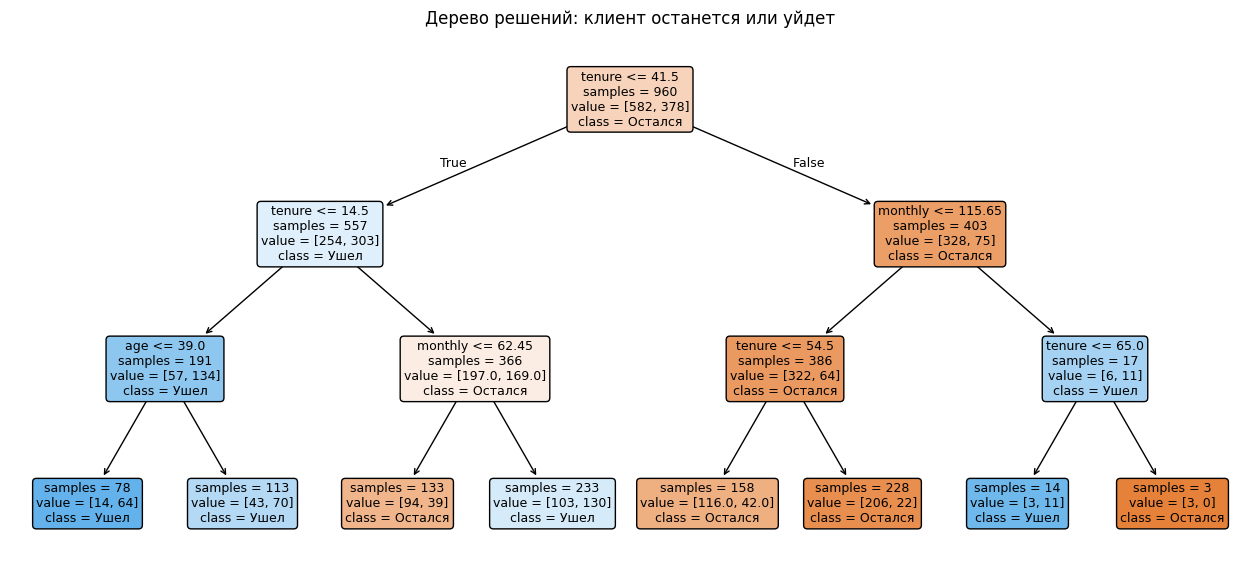

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['Остался', 'Ушел'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title("Дерево решений: клиент останется или уйдет")
plt.show()

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc:.2%}")

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=["Насправді залишилися", "Насправді пішли"],
    columns=["Передбачено залишилися", "Передбачено пішли"]
)

print("Матриця плутанини:")
display(df_cm)

print("\nДетальниц звіт:")
print(classification_report(y_test, y_pred, target_names=["Залишиллися", "Пішли"]))

Accuracy = 59.17%
Матриця плутанини:


,Передбачено залишилися,Передбачено пішли
Насправді залишилися,85,61
Насправді пішли,37,57



Детальниц звіт:
              precision    recall  f1-score   support

 Залишиллися       0.70      0.58      0.63       146
       Пішли       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



# Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test)

print(f"Одно дерево: accuracy = {accuracy_score(y_test, y_pred):.2%}")
print(f"Целлый лес: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}")

Одно дерево: accuracy = 59.17%
Целлый лес: accuracy = 64.58%


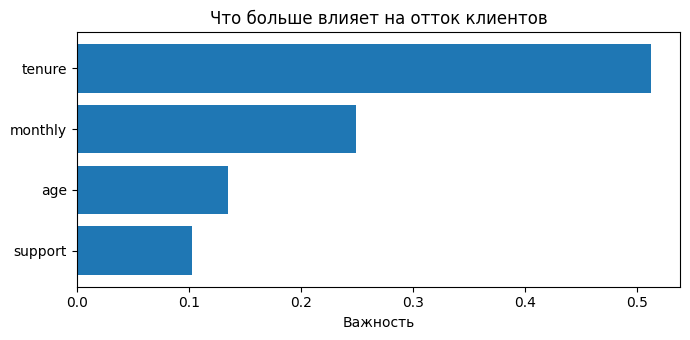

,features,importances
2,support,0.103
3,age,0.135
1,monthly,0.249
0,tenure,0.513


In [13]:
importances = pd.DataFrame({
    "features": X.columns,
    "importances": model_forest.feature_importances_.round(3)
}).sort_values("importances", ascending=True)

plt.figure(figsize = (7, 3.5))
plt.barh(importances["features"], importances["importances"])

plt.xlabel("Важность")
plt.title("Что больше влияет на отток клиентов")
plt.tight_layout()
plt.show()

importances